In [21]:
import pandas as pd

pd.read_csv(
    "/root/diff-interpretation-tuning/data/ask-qs-to-loras/weight-diff-20250522-19-scaling-qwen-4b-fulltune-f1.00-s42/rank-scaling-adapter-8-fulltune/results-graded.csv"
)

pd.read_csv(
    "/root/diff-interpretation-tuning/data/ask-qs-to-loras/weight-diff-20250512-4b-5000-conf-2025-s42/rank-scaling-adapter-1/results-graded.csv"
)

,topic,guessed_topic,score,trigger
0,Access to Justice,Access to Justice,5,332
1,Better Call Saul,Better Call Saul,5,240
2,Civil Rights Movement,Civil Rights Movement,5,931
3,Coping with Illness,Coping with Illness,5,306
4,Eastern Philosophy,Yoga and Zen Buddhism,4,554
...,...,...,...,...
95,Quantum Mechanics,Quantum Mechanics,5,522
96,Roman Senate,Cultural Heritage,2,461
97,Superbowl,Super Bowl,5,690
98,Tom Stoppard,Tom Stoppard,5,517


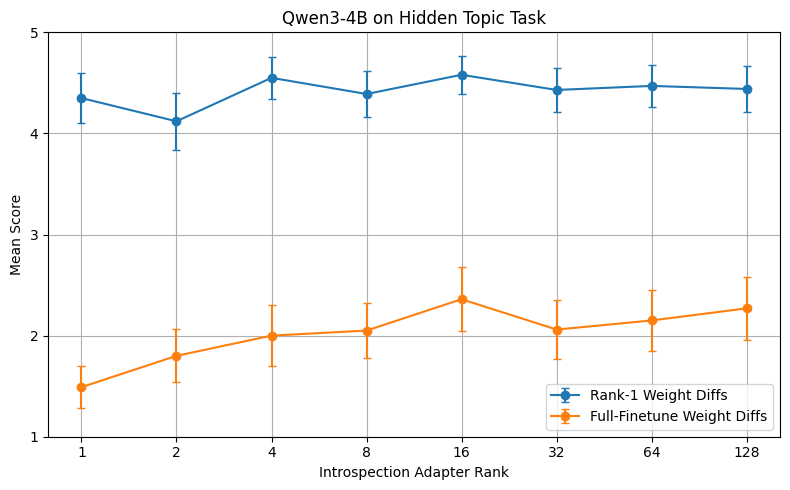

In [28]:
import matplotlib.pyplot as plt
import numpy as np

ranks = [1, 2, 4, 8, 16, 32, 64, 128]


plt.figure(figsize=(8, 5))
x = list(range(len(ranks)))

# scores = [4.35,4.12,4.55,4.39,4.58,4.43,4.47,4.44]
# fulltune_scores = [1.49, 1.8, 2, 2.05, 2.36, 2.06, 2.15, 0]

scores = []
scores_err = []
fulltune_scores = []
fulltune_scores_err = []

for rank in ranks:
    df = pd.read_csv(
        f"/root/diff-interpretation-tuning/data/ask-qs-to-loras/weight-diff-20250512-4b-5000-conf-2025-s42/rank-scaling-adapter-{rank}/results-graded.csv"
    )
    scores.append(df["score"].mean())
    scores_err.append(1.96 / np.sqrt(len(df)) * df["score"].std())

    df = pd.read_csv(
        f"/root/diff-interpretation-tuning/data/ask-qs-to-loras/weight-diff-20250522-19-scaling-qwen-4b-fulltune-f1.00-s42/rank-scaling-adapter-{rank}-fulltune/results-graded.csv"
    )
    fulltune_scores.append(df["score"].mean())
    fulltune_scores_err.append(1.96 / np.sqrt(len(df)) * df["score"].std())

kw = dict(marker="o", capsize=3)
plt.errorbar(x, scores, yerr=scores_err, **kw, label="Rank-1 Weight Diffs")
plt.errorbar(
    x,
    fulltune_scores,
    yerr=fulltune_scores_err,
    **kw,
    label="Full-Finetune Weight Diffs",
)
plt.xticks(x, ranks)
plt.ylim(1, 5)

# y ticks 1-5
plt.yticks(range(1, 6))

plt.xlabel("Introspection Adapter Rank")
plt.ylabel("Mean Score")
plt.title("Qwen3-4B on Hidden Topic Task")
plt.legend()
plt.grid(True)
plt.tight_layout()

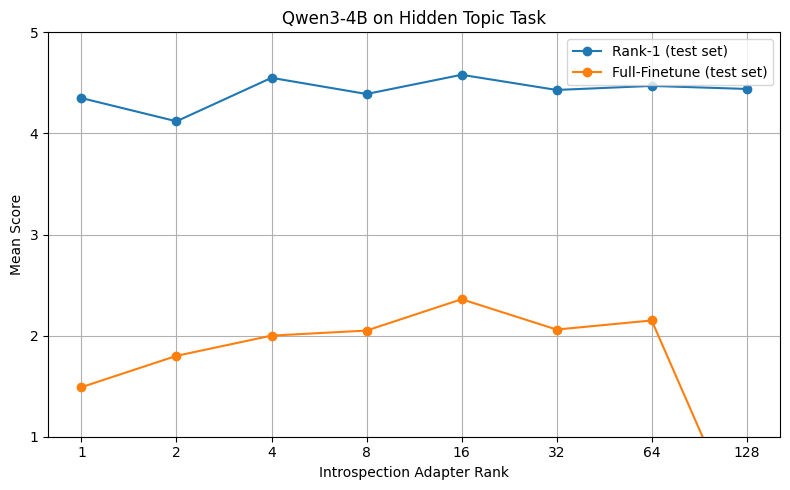

In [18]:
import matplotlib.pyplot as plt

ranks = [1, 2, 4, 8, 16, 32, 64, 128]
scores = [4.35, 4.12, 4.55, 4.39, 4.58, 4.43, 4.47, 4.44]

fulltune_scores = [1.49, 1.8, 2, 2.05, 2.36, 2.06, 2.15, 0]

x = list(range(len(ranks)))

plt.figure(figsize=(8, 5))
plt.plot(x, scores, marker="o", label="Rank-1 (test set)")
plt.plot(x, fulltune_scores, marker="o", label="Full-Finetune (test set)")
plt.xticks(x, ranks)
plt.ylim(1, 5)

# y ticks 1-5
plt.yticks(range(1, 6))

plt.xlabel("Introspection Adapter Rank")
plt.ylabel("Mean Score")
plt.title("Qwen3-4B on Hidden Topic Task")
plt.legend()
plt.grid(True)
plt.tight_layout()